# library

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# data

In [2]:
data = pd.read_excel(r'formated_data\WDI_full_collected.xlsx')

In [3]:
data = data.pivot_table(index=['Country Name', 'Year'],
                       columns=['Series Name'],
                                 values=['Value'],
                                 aggfunc='sum')#.to_excel(r'wdi_piovt.xlsx')

In [4]:
data.columns = data.columns.droplevel(0) 

In [5]:
data['Domestic credit to private sector (constant 2015 US$)'] = data['Domestic credit to private sector (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Market capitalization of listed domestic companies (constant 2015 US$)'] = data['Market capitalization of listed domestic companies (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Exports of goods and services (constant 2015 US$)'] = data['Exports of goods and services (% of GDP)'] * data['GDP (constant 2015 US$)']/100

In [6]:
data_test_df = data.copy()

In [7]:
data_test_df.rename(columns={'Domestic credit to private sector (constant 2015 US$)' : 'Domestic credit'
                             , 'Exports of goods and services (constant 2015 US$)' : 'Exports'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Market capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

In [8]:
data_test_df

Series Name        Domestic credit to private sector (% of GDP)  \
Country Name Year                                                 
China        1990                                     86.033020   
             1991                                     88.101074   
             1992                                     86.053063   
             1993                                     96.506392   
             1994                                     85.487555   
...                                                         ...   
India        2020                                     54.505290   
             2021                                     50.142158   
             2022                                     55.576000   
             2023                                     59.775785   
             2024                                     60.604894   

Series Name        Exports of goods and services (% of GDP)           GDP  \
Country Name Year                                                           
China        1990                                 13.588264  1.041272e+12   
             1991                                 14.445032  1.138753e+12   
             1992                                 15.600241  1.301590e+12   
             1993                                 16.633998  1.482889e+12   
             1994                                 18.451578  1.676743e+12   
...                                                     ...           ...   
India        2020                                 18.682477  2.533830e+12   
             2021                                 21.399158  2.779348e+12   
             2022                                 23.251541  2.990839e+12   
             2023                                 21.448698  3.265720e+12   
             2024                                 21.161846  3.477821e+12   

Series Name        GDP (current US$)  \
Country Name Year                      
China        1990       3.615602e+11   
             1991       3.845105e+11   
             1992       4.285024e+11   
             1993       4.465573e+11   
             1994       5.669295e+11   
...                              ...   
India        2020       2.674852e+12   
             2021       3.167271e+12   
             2022       3.346107e+12   
             2023       3.638489e+12   
             2024       3.909892e+12   

Series Name        Market capitalization of listed domestic companies (% of GDP)  \
Country Name Year                                                                  
China        1990                                           0.000000               
             1991                                           0.534959               
             1992                                           4.329716               
             1993                                           9.216773               
             1994                                           7.778633               
...                                                              ...               
India        2020                                          95.424502               
             2021                                         112.021323               
             2022                                         101.233056               
             2023                                         119.283875               
             2024                                         131.241427               

Series Name        Domestic credit  Market capitalization       Exports  
Country Name Year                                                        
China        1990     8.958377e+11           0.000000e+00  1.414908e+11  
             1991     1.003253e+12           6.091855e+09  1.644932e+11  
             1992     1.120058e+12           5.635514e+10  2.030512e+11  
             1993     1.431083e+12           1.366746e+11  2.466638e+11  
             1994     1.433407e+12           1.304277e+11  3.093856e

# viz

## level

In [9]:
data_test_df.to_excel(r'explore_data\_WDI_level.xlsx', index=True)

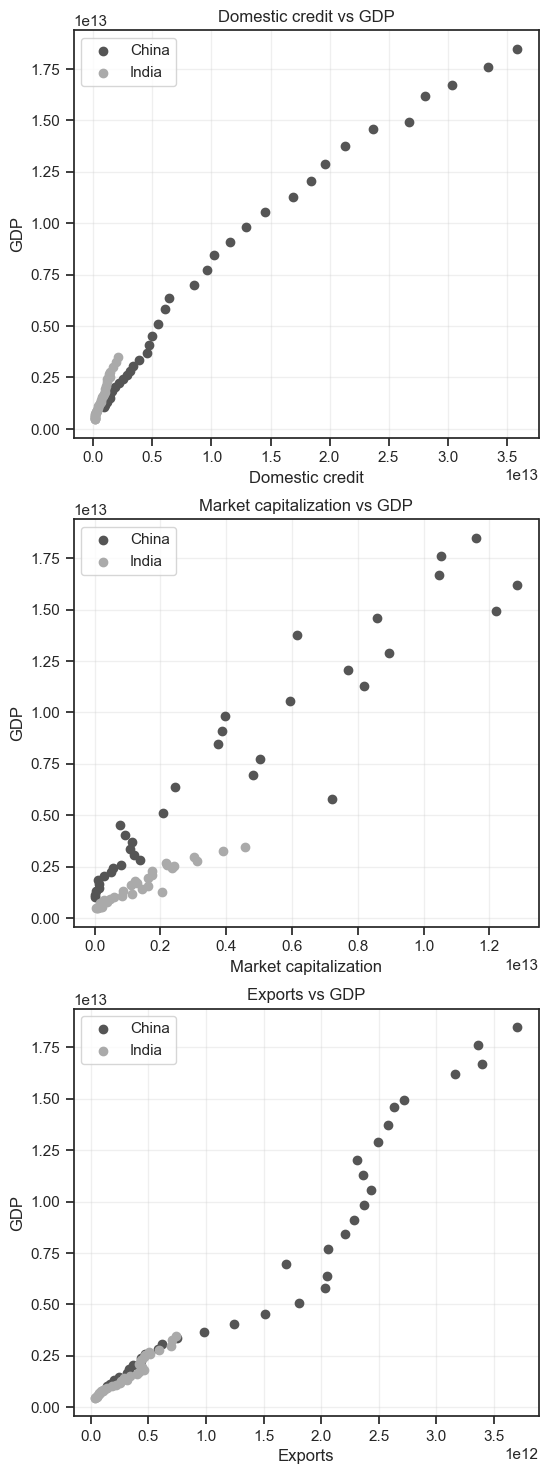

In [10]:
sns.set_theme(style="ticks", font_scale=1)
# Create visualization to understand the data
fig, axes = plt.subplots(3, 1, figsize=(6, 18))


# 2. R&D spending trends
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0].scatter(data_test_df_temp['Domestic credit']
                       , data_test_df_temp['GDP']
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[0].set_xlabel('Domestic credit')
    axes[0].set_ylabel('GDP')
    axes[0].set_title('Domestic credit vs GDP')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()


# 3. Scatter plot: R&D vs Profit Margin
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1].scatter(data_test_df_temp['Market capitalization']
                       , data_test_df_temp['GDP']                       
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[1].set_xlabel('Market capitalization')
    axes[1].set_ylabel('GDP')
    axes[1].set_title('Market capitalization vs GDP')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

# 4. Boxplot by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[2].scatter(data_test_df_temp['Exports']
                       , data_test_df_temp['GDP']
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[2].set_xlabel('Exports')
    axes[2].set_ylabel('GDP')
    axes[2].set_title('Exports vs GDP')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
plt.savefig(r'explore_data\_anual_comparisons.png', dpi=300)
plt.show()

## diff

In [11]:
data_test_df = pd.DataFrame()

for country in data.index.get_level_values(0).unique():
    country_df = data.loc[country].diff(1)
    country_df = country_df.iloc[1:].reset_index()
    
    # country_df = data.loc[country].pct_change(1)
    # country_df = country_df.iloc[2:].reset_index()
    
    country_df['Country Name'] = country
    data_test_df = pd.concat([data_test_df, country_df])    

data_test_df = data_test_df.set_index(['Country Name', 'Year'])

data_test_df.rename(columns={'Domestic credit to private sector (constant 2015 US$)' : 'Credit'
                             , 'Exports of goods and services (constant 2015 US$)' : 'Exports'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

data_test_df = data_test_df[['GDP'
                             , 'Credit'
                             , 'Capitalization'
                             , 'Exports'
                            ]].dropna()

In [12]:
data_test_df.to_excel(r'explore_data\_WDI_diff.xlsx', index=True)

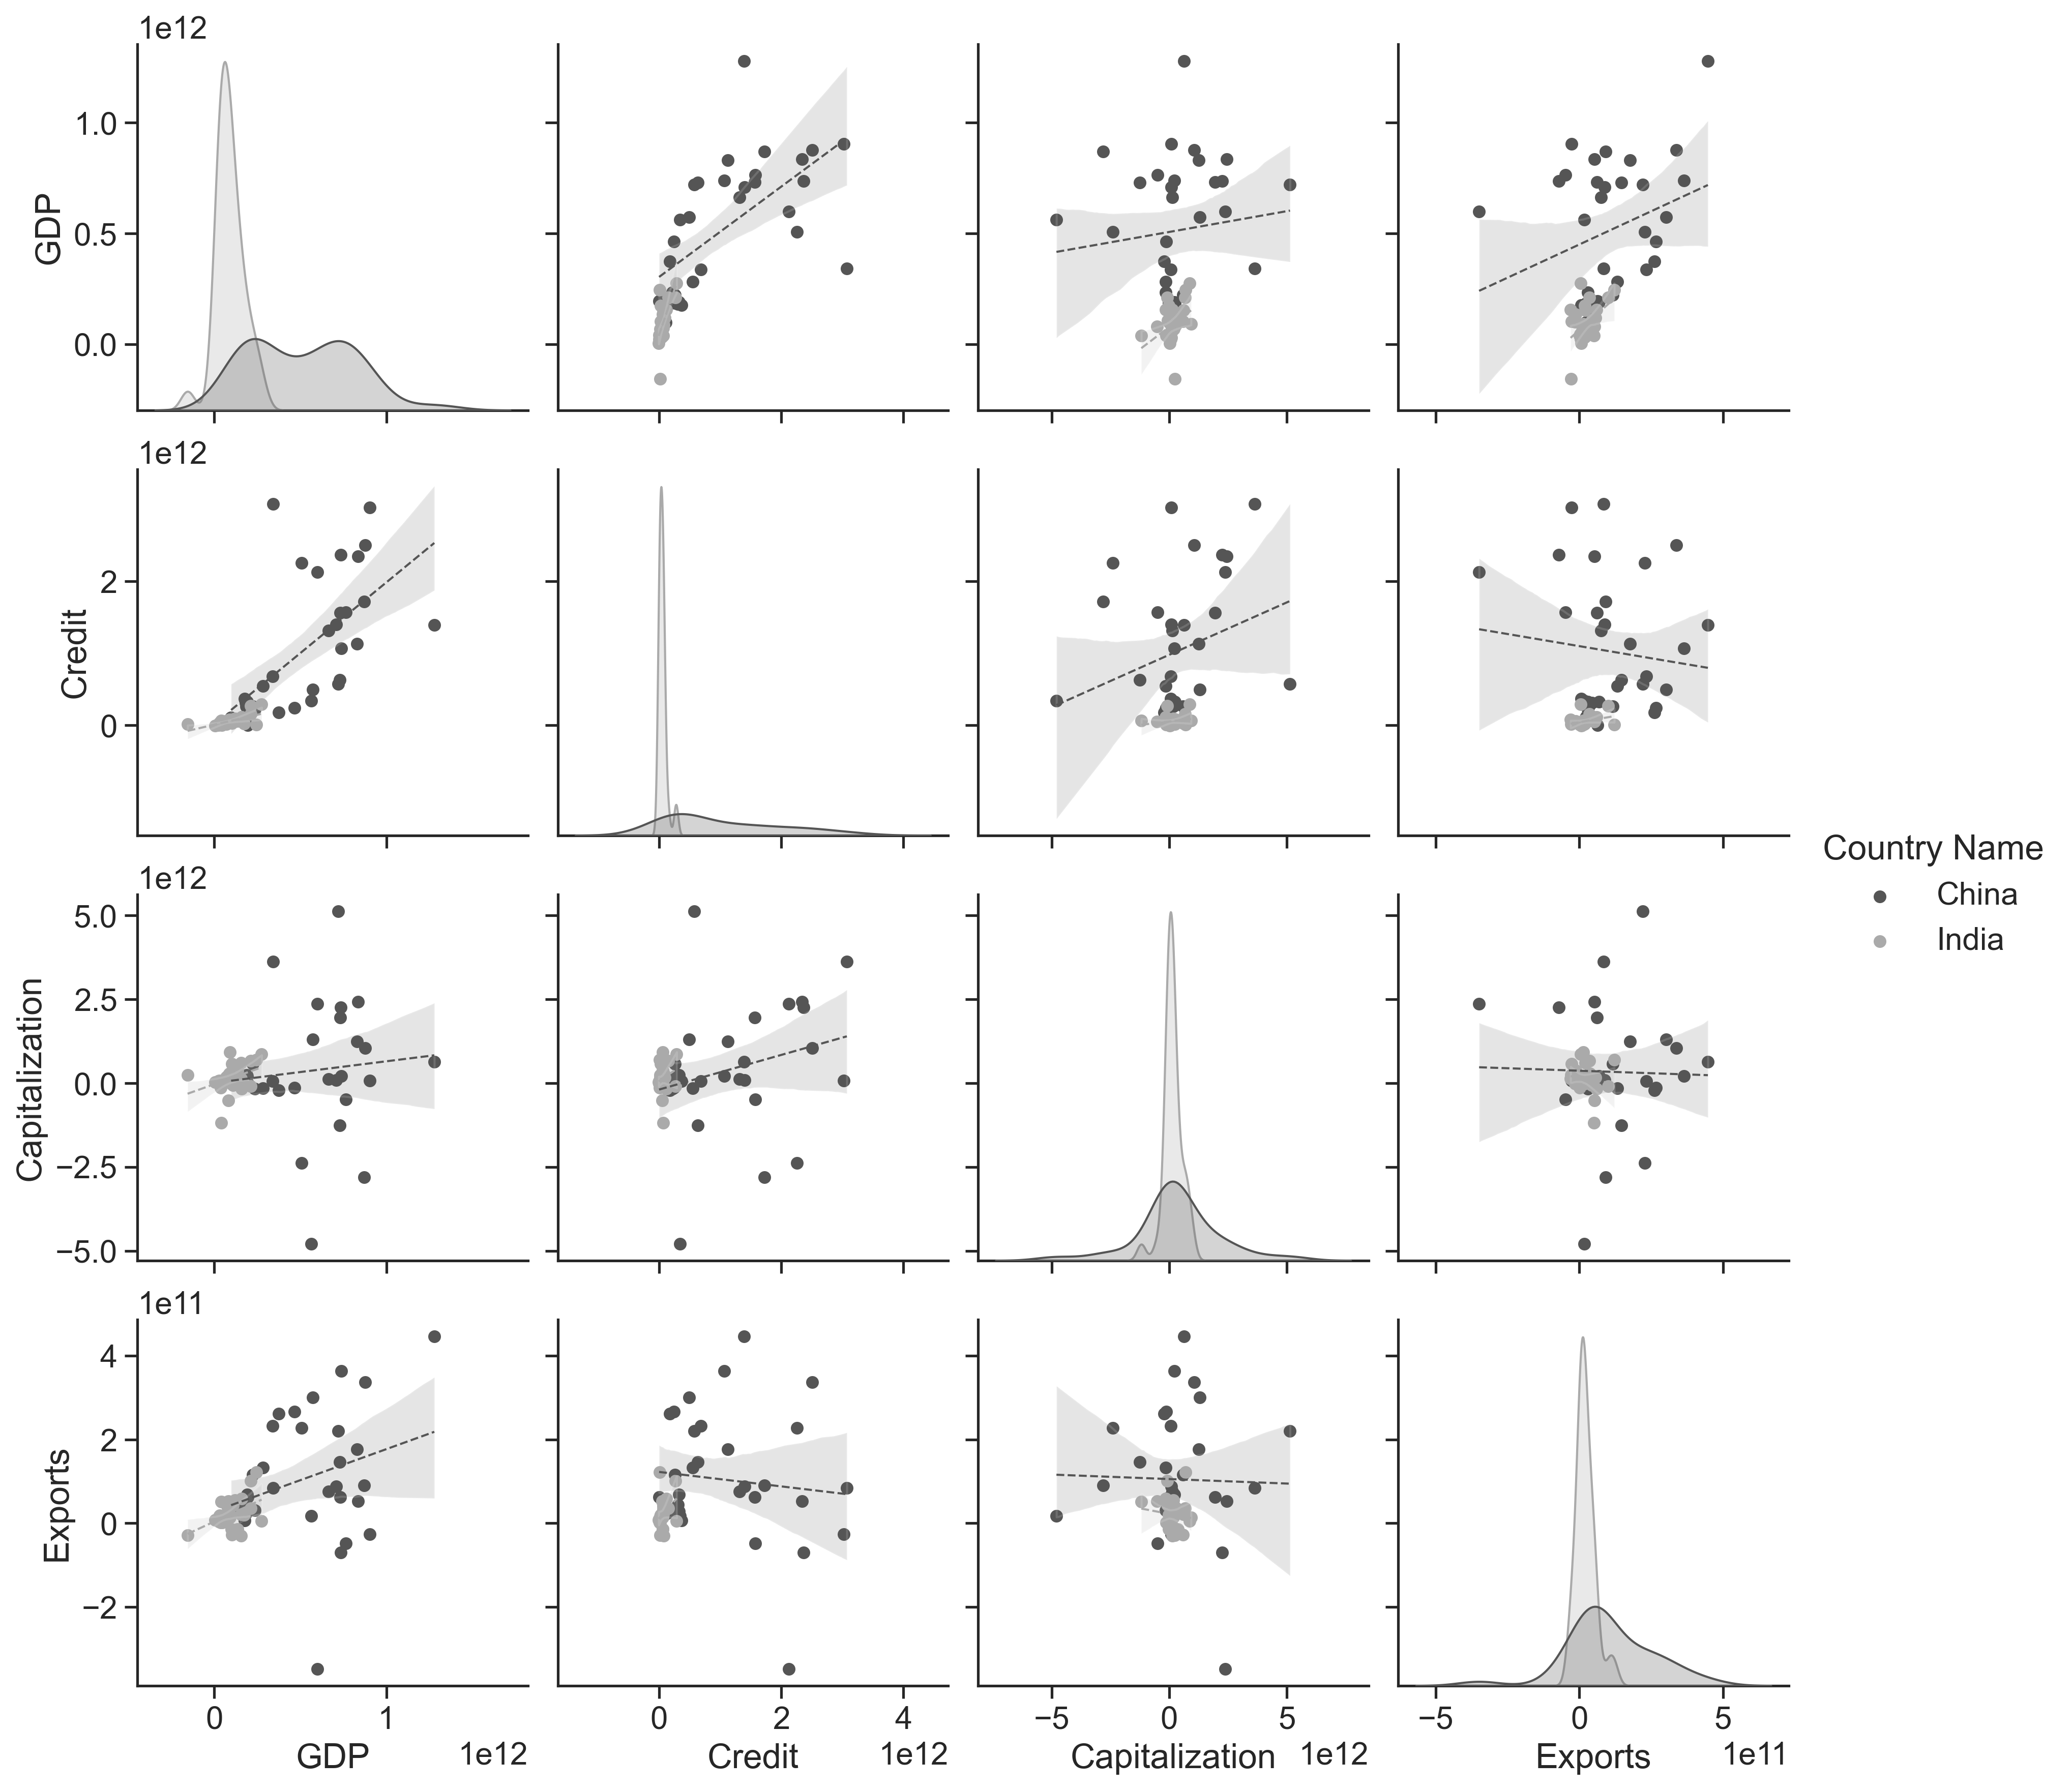

In [13]:
sns.set_theme(style="ticks", font_scale=1.35, rc={'figure.figsize': (10, 6), 'figure.dpi': 300})

sns.pairplot(
    data_test_df.reset_index()[['Country Name'
                                , 'GDP'
                                , 'Credit'
                                , 'Capitalization'
                                , 'Exports'
                               ]]
    
    , hue = 'Country Name'
    
    , palette = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique()))
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 1}
               }
    , dropna=True
)
    
plt.savefig(r'explore_data\_anual_abs_growth.png', dpi=300)
plt.show()

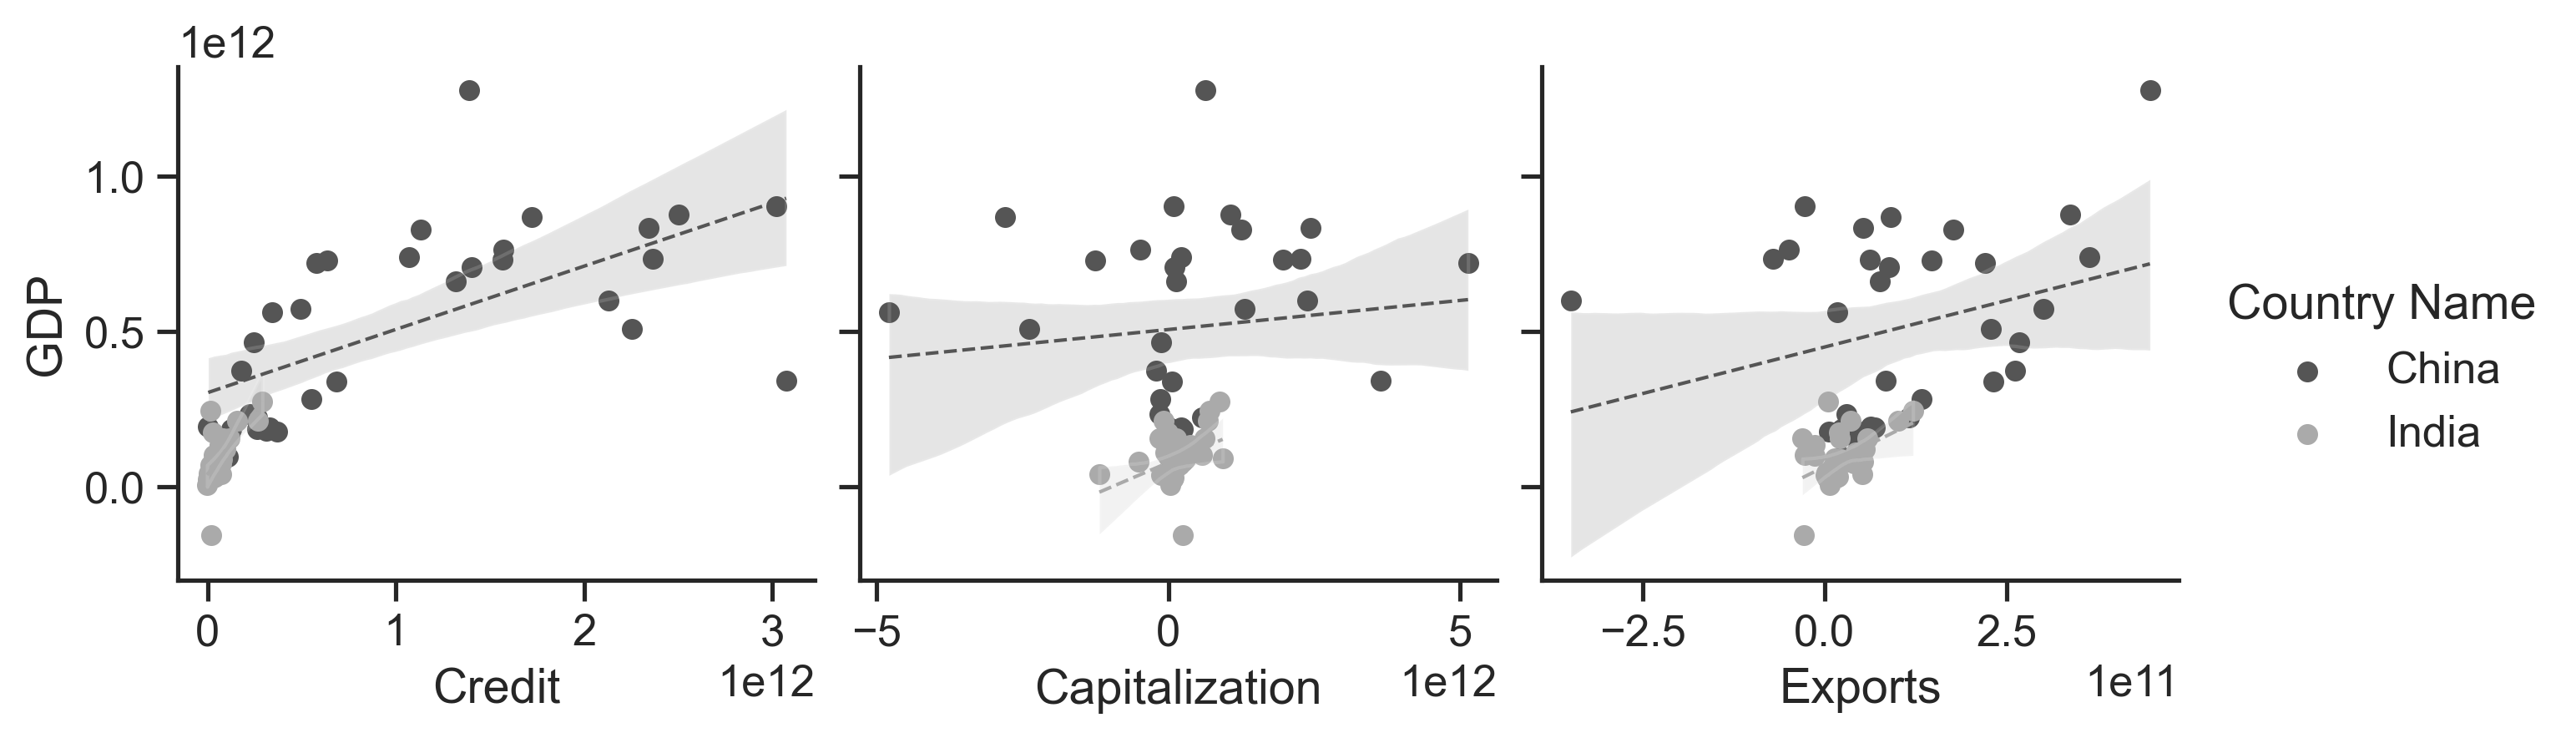

In [14]:
sns.set_theme(style="ticks", font_scale=1.15, rc={'figure.figsize': (10, 6), 'figure.dpi': 300})

sns.pairplot(
    data_test_df.reset_index()[['Country Name'
                                , 'GDP'
                                , 'Credit'
                                , 'Capitalization'
                                , 'Exports'
                               ]]
    
    , hue = 'Country Name'
    , y_vars = ['GDP']
    , x_vars = ['Credit'
                , 'Capitalization'
                , 'Exports']
    
    , palette = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique()))
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 1}
               }
    , dropna=True
)
    
plt.savefig(r'explore_data\_anual_abs_growth_comparisons.png', dpi=300)
plt.show()

In [15]:
data_test_df

Series Name                 GDP        Credit  Capitalization       Exports
Country Name Year                                                          
China        1991  9.748077e+10  1.074157e+11    6.091855e+09  2.300242e+10
             1992  1.628372e+11  1.168046e+11    5.026329e+10  3.855797e+10
             1993  1.812995e+11  3.110250e+11    8.031941e+10  4.361262e+10
             1994  1.938538e+11  2.323724e+09   -6.246853e+09  6.272179e+10
             1995  1.849919e+11  1.264163e+11   -2.288037e+10  2.316554e+10
...                         ...           ...             ...           ...
India        2020 -1.553749e+11  1.650265e+10    2.490434e+11 -2.853812e+10
             2021  2.455178e+11  1.255358e+10    6.955677e+11  1.213749e+11
             2022  2.114908e+11  2.685635e+11   -8.574497e+10  1.006590e+11
             2023  2.748807e+11  2.899209e+11    8.677593e+11  5.038183e+09
             2024  2.121008e+11  1.556199e+11    6.688643e+11  3.551668e+10

[68 rows x 4 columns]

# model

In [16]:
# Prepare variables
# Note: linearmodels requires explicit addition of constant for some models
X = data_test_df[['Credit'
                  , 'Capitalization'
                  , 'Exports'
                 ]]
y = data_test_df['GDP']

# Add constant for models that need it
X_with_const = sm.add_constant(X)

print("="*60)
print("PANEL DATA REGRESSION RESULTS")
print("="*60)

# 1. POOLED OLS (ignores panel structure)
print("\n1. POOLED OLS MODEL")
print("-"*40)
pooled_model = PooledOLS(y, X_with_const)
pooled_results = pooled_model.fit(cov_type='robust')
print(pooled_results)

# 2. FIXED EFFECTS MODEL (entity effects)
print("\n2. FIXED EFFECTS MODEL (entity)")
print("-"*40)
# entity_effects=True includes fixed effects for each company
efe_model = PanelOLS(y, X, entity_effects=True, time_effects=False)
efe_results = efe_model.fit(cov_type='clustered', cluster_entity=True)
print(efe_results)

# 3. FIXED EFFECTS MODEL (time effects)
print("\n3 . FIXED EFFECTS MODEL (time)")
print("-"*40)
# time_effects=True includes fixed effects for each year
tfe_model = PanelOLS(y, X, entity_effects=False, time_effects=True)
tfe_results = tfe_model.fit(cov_type='clustered', cluster_entity=True)
print(tfe_results)

# 4. RANDOM EFFECTS MODEL
print("\n4. RANDOM EFFECTS MODEL")
print("-"*40)
re_model = RandomEffects(y, X_with_const)
re_results = re_model.fit(cov_type='robust')
print(re_results)

# 5. TWO-WAY FIXED EFFECTS (entity + time effects)
print("\n5. TWO-WAY FIXED EFFECTS MODEL")
print("-"*40)
twfe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
twfe_results = twfe_model.fit(cov_type='clustered', cluster_entity=True)
print(twfe_results)

PANEL DATA REGRESSION RESULTS

1. POOLED OLS MODEL
----------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:                    GDP   R-squared:                        0.7285
Estimator:                  PooledOLS   R-squared (Between):              0.9642
No. Observations:                  68   R-squared (Within):               0.4982
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.7285
Time:                        11:03:21   Log-likelihood                   -1849.6
Cov. Estimator:                Robust                                           
                                        F-statistic:                      57.240
Entities:                           2   P-value                           0.0000
Avg Obs:                       34.000   Distribution:                    F(3,64)
Min Obs:                       34.000                                           
Max Obs:         

## diagnostics

In [17]:
print(compare({'Pooled' : pooled_results
               , 'Fixed (e)' : efe_results
               , 'Fixed (t)' : tfe_results
               , 'Random' : re_results
               , 'Two way' : twfe_results
              }
              , precision = "pvalues"
              , stars=True)
     )

                                           Model Comparison                                           
                                  Pooled     Fixed (e)      Fixed (t)            Random        Two way
------------------------------------------------------------------------------------------------------
Dep. Variable                        GDP           GDP            GDP               GDP            GDP
Estimator                      PooledOLS      PanelOLS       PanelOLS     RandomEffects       PanelOLS
No. Observations                      68            68             68                68             68
Cov. Est.                         Robust     Clustered      Clustered            Robust      Clustered
R-squared                         0.7285        0.5265         0.8300            0.7285         0.5079
R-Squared (Within)                0.4982        0.5265         0.4781            0.4982         0.5114
R-Squared (Between)               0.9642        0.8296         0.9387    

In [18]:
# Null Hypothesis: Homoscedasticity is present (constant variance)
# Alternative Hypothesis: Heteroscedasticity is present

# Returns: LM Statistic, LM p-value, F-Statistic, F-p-value
bp_test = het_breuschpagan(pooled_results.resids, X_with_const)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
pd.DataFrame.from_dict([dict(zip(labels, bp_test))])

,LM Statistic,LM-Test p-value,F-Statistic,F-Test p-value
0,23.245445,0.000036,11.0805,0.000006


In [20]:
# FIXED EFFECTS MODEL (entity)
common_vars = ['Credit', 'Capitalization', 'Exports']
b_fe = efe_results.params[common_vars]
b_re = re_results.params[common_vars]

# Covariance matrices
cov_fe = efe_results.cov.loc[common_vars, common_vars]
cov_re = re_results.cov.loc[common_vars, common_vars]

# Hausman statistic
diff = b_fe - b_re
cov_diff = cov_fe - cov_re
hausman_stat = diff @ np.linalg.inv(cov_diff) @ diff
df = len(common_vars)
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print(f"Hausman test: chi2={hausman_stat:.4f}, df={df}, p-value={p_value:.4f}")

Hausman test: chi2=-1.8783, df=3, p-value=1.0000


In [21]:
# FIXED EFFECTS MODEL (time)
b_fe = tfe_results.params[common_vars]
b_re = re_results.params[common_vars]

# Covariance matrices
cov_fe = tfe_results.cov.loc[common_vars, common_vars]
cov_re = re_results.cov.loc[common_vars, common_vars]

# Hausman statistic
diff = b_fe - b_re
cov_diff = cov_fe - cov_re
hausman_stat = diff @ np.linalg.inv(cov_diff) @ diff
df = len(common_vars)
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print(f"Hausman test: chi2={hausman_stat:.4f}, df={df}, p-value={p_value:.4f}")

Hausman test: chi2=-0.3250, df=3, p-value=1.0000


In [22]:
# FIXED EFFECTS MODEL (entity and time)
b_fe = twfe_results.params[common_vars]
b_re = re_results.params[common_vars]

# Covariance matrices
cov_fe = twfe_results.cov.loc[common_vars, common_vars]
cov_re = re_results.cov.loc[common_vars, common_vars]

# Hausman statistic
diff = b_fe - b_re
cov_diff = cov_fe - cov_re
hausman_stat = diff @ np.linalg.inv(cov_diff) @ diff
df = len(common_vars)
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print(f"Hausman test: chi2={hausman_stat:.4f}, df={df}, p-value={p_value:.4f}")

Hausman test: chi2=-5.3178, df=3, p-value=1.0000


## viz

In [23]:
sns.set_theme(style="ticks", font_scale=1, rc={'figure.figsize': (6, 3), 'figure.dpi': 150})

### pooled_results

In [24]:
pooled_resid_df = pooled_results.resids.reset_index().pivot_table(index=['Year'],
                                                                  columns=['Country Name'],
                                                                  values=['residual'],
                                                                  aggfunc='sum')
pooled_resid_df.columns = pooled_resid_df.columns.droplevel(0) 

<Axes: xlabel='Year'>

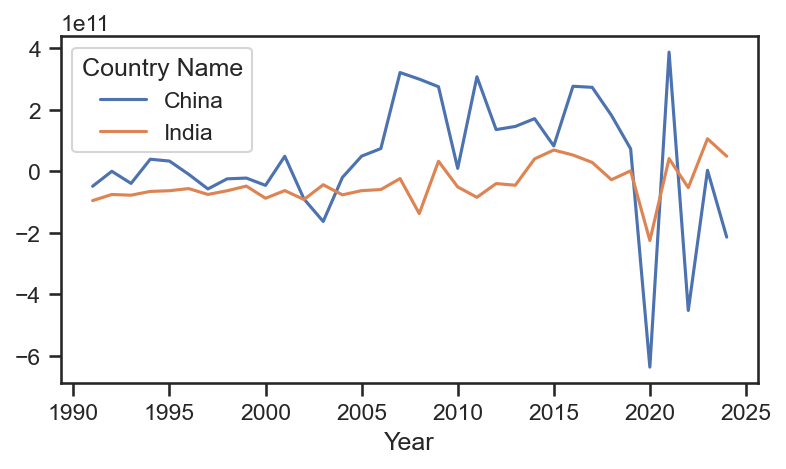

In [25]:
pooled_resid_df.plot()

<Axes: ylabel='Density'>

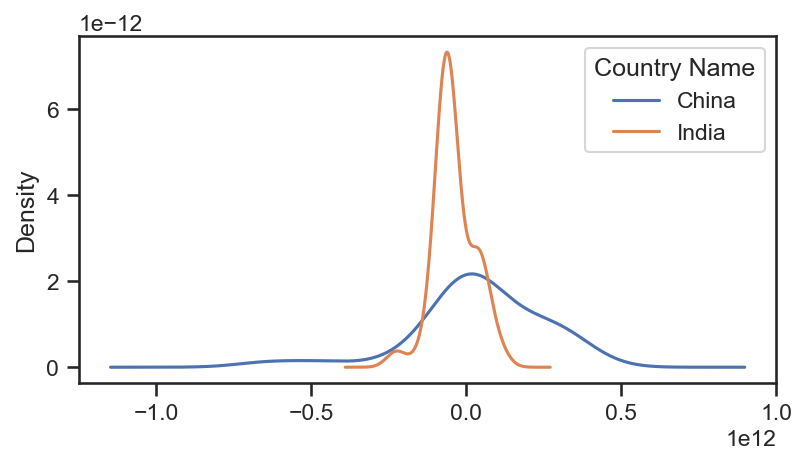

In [26]:
pooled_resid_df.plot(kind='kde')

### efe_results

In [27]:
efe_resid_df = efe_results.resids.reset_index().pivot_table(index=['Year'],
                                                                  columns=['Country Name'],
                                                                  values=['residual'],
                                                                  aggfunc='sum')
efe_resid_df.columns = efe_resid_df.columns.droplevel(0) 

<Axes: xlabel='Year'>

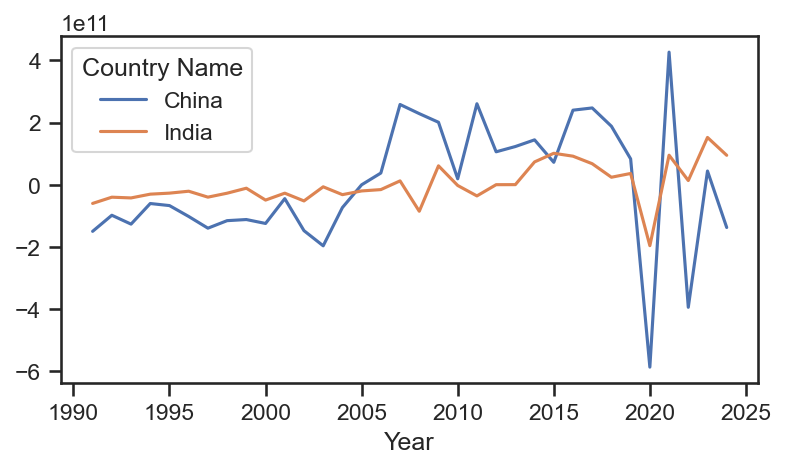

In [28]:
efe_resid_df.plot()

<Axes: ylabel='Density'>

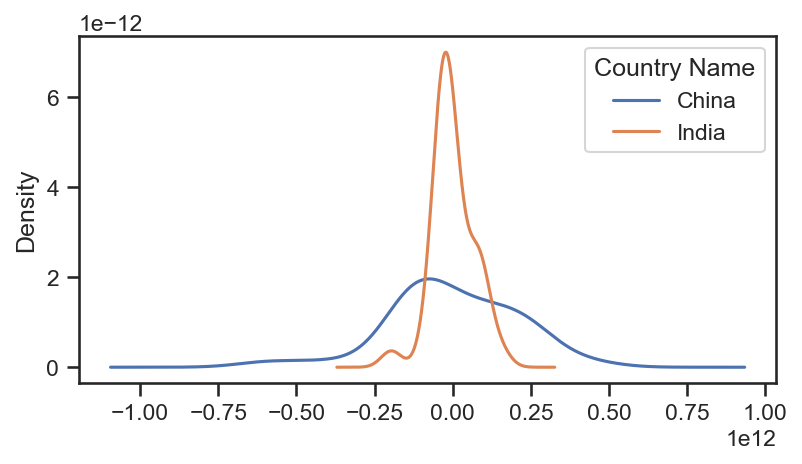

In [29]:
efe_resid_df.plot(kind='kde')

### tfe_results

In [30]:
tfe_resid_df = tfe_results.resids.reset_index().pivot_table(index=['Year'],
                                                                  columns=['Country Name'],
                                                                  values=['residual'],
                                                                  aggfunc='sum')
tfe_resid_df.columns = tfe_resid_df.columns.droplevel(0) 

<Axes: xlabel='Year'>

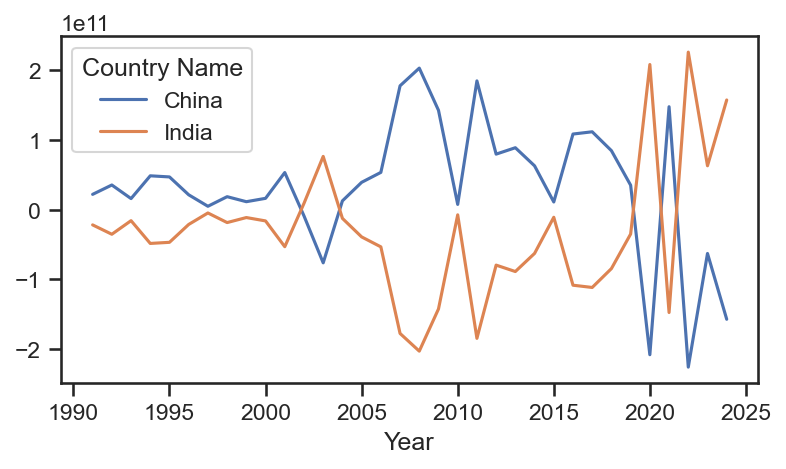

In [31]:
tfe_resid_df.plot()

<Axes: ylabel='Density'>

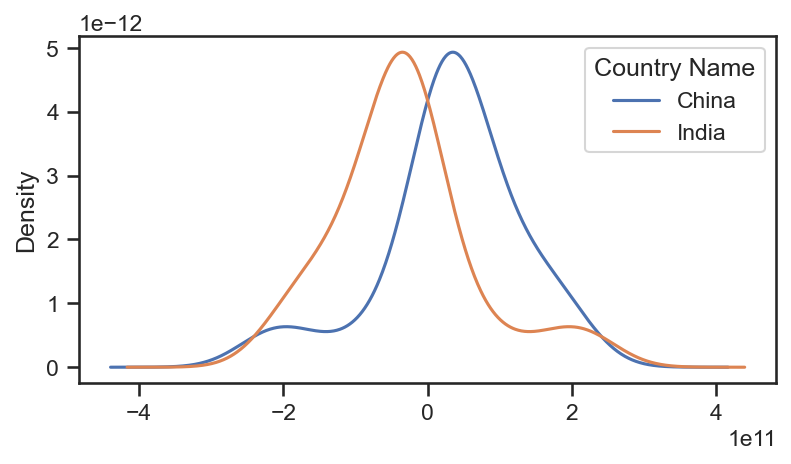

In [32]:
tfe_resid_df.plot(kind='kde')

### re_results

In [33]:
re_resid_df = re_results.resids.reset_index().pivot_table(index=['Year'],
                                                                  columns=['Country Name'],
                                                                  values=['residual'],
                                                                  aggfunc='sum')
re_resid_df.columns = re_resid_df.columns.droplevel(0) 

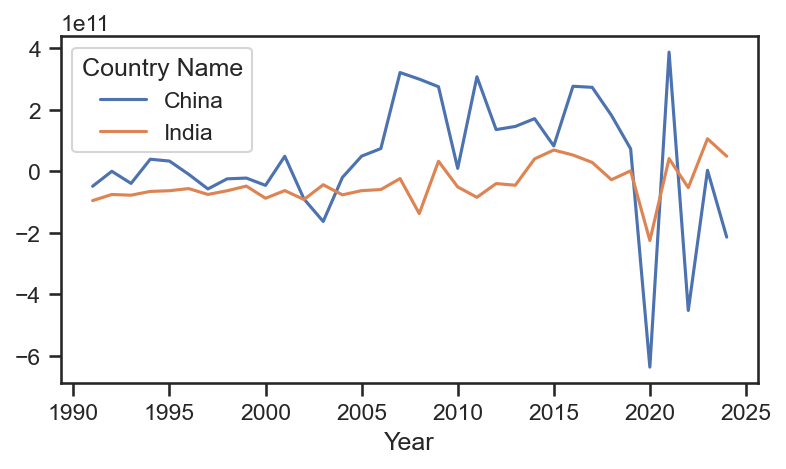

In [34]:
re_resid_df.plot()
plt.savefig(r'explore_data\_re_model_residuals_line.png', dpi=150)
plt.show()

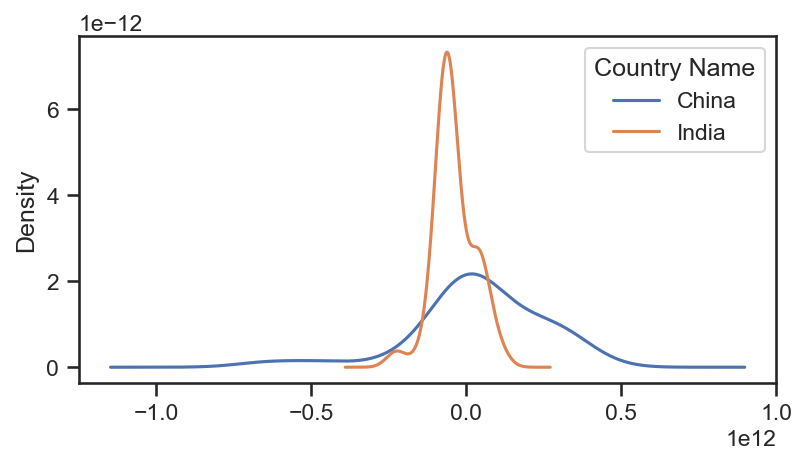

In [35]:
re_resid_df.plot(kind='kde')
plt.savefig(r'explore_data\_re_model_residuals_kde.png', dpi=150)
plt.show()

### twfe_results

In [36]:
twfe_resid_df = twfe_results.resids.reset_index().pivot_table(index=['Year'],
                                                                  columns=['Country Name'],
                                                                  values=['residual'],
                                                                  aggfunc='sum')
twfe_resid_df.columns = twfe_resid_df.columns.droplevel(0) 

<Axes: xlabel='Year'>

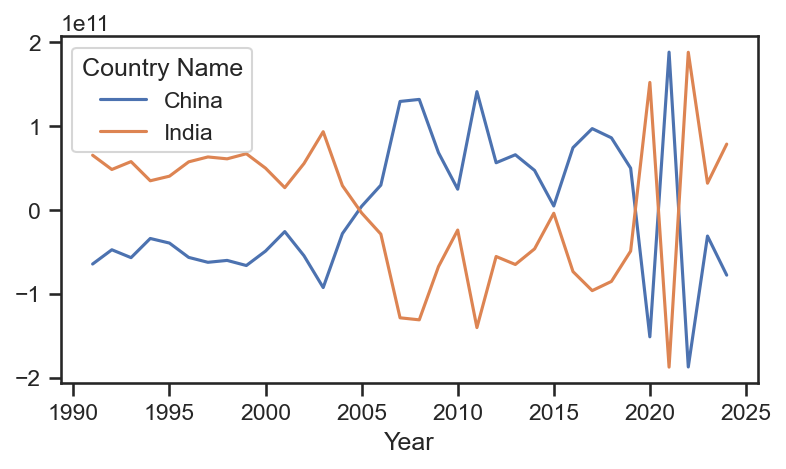

In [37]:
twfe_resid_df.plot()

<Axes: ylabel='Density'>

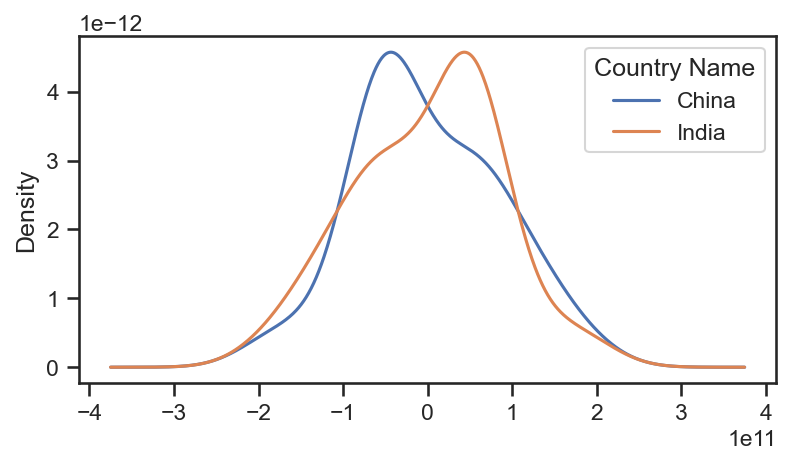

In [38]:
twfe_resid_df.plot(kind='kde')